In [54]:
pip install torch torchvision pillow

In [55]:
import torch

In [56]:
from PIL import Image
import torchvision.transforms as transforms

img = Image.open("/content/Screenshot (2).png").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img_tensor = transform(img)
print(img_tensor)

tensor([[[0.1137, 0.1373, 0.1529,  ..., 0.2392, 0.2078, 0.2000],
         [0.3686, 0.4980, 0.5608,  ..., 0.6392, 0.6078, 0.5804],
         [0.5294, 0.6471, 0.6706,  ..., 0.6863, 0.6667, 0.6471],
         ...,
         [0.1490, 0.5490, 0.6510,  ..., 0.6196, 0.6706, 0.6471],
         [0.1373, 0.5255, 0.6353,  ..., 0.6588, 0.6549, 0.6314],
         [0.1255, 0.4980, 0.6235,  ..., 0.6510, 0.6353, 0.6078]],

        [[0.1765, 0.2039, 0.2196,  ..., 0.3137, 0.2863, 0.2784],
         [0.4235, 0.5608, 0.6275,  ..., 0.7098, 0.6784, 0.6510],
         [0.5843, 0.7176, 0.7451,  ..., 0.7569, 0.7412, 0.7176],
         ...,
         [0.1490, 0.5922, 0.7059,  ..., 0.6745, 0.7294, 0.7137],
         [0.1373, 0.5686, 0.6941,  ..., 0.7176, 0.7137, 0.6941],
         [0.1255, 0.5412, 0.6824,  ..., 0.7098, 0.6980, 0.6706]],

        [[0.2902, 0.3294, 0.3647,  ..., 0.4784, 0.4392, 0.4275],
         [0.6157, 0.7490, 0.8157,  ..., 0.8941, 0.8627, 0.8353],
         [0.7922, 0.9059, 0.9294,  ..., 0.9412, 0.9216, 0.

In [57]:
img_tensor = img_tensor.unsqueeze(0)
print(img_tensor.shape)

torch.Size([1, 3, 224, 224])


In [58]:
kernel = torch.full((5,5), 0.04)
kernel

tensor([[0.0400, 0.0400, 0.0400, 0.0400, 0.0400],
        [0.0400, 0.0400, 0.0400, 0.0400, 0.0400],
        [0.0400, 0.0400, 0.0400, 0.0400, 0.0400],
        [0.0400, 0.0400, 0.0400, 0.0400, 0.0400],
        [0.0400, 0.0400, 0.0400, 0.0400, 0.0400]])

In [59]:
import torch.nn.functional as F
blur_weight = kernel.expand(3,3,5,5).contiguous()
output = F.conv2d(img_tensor, blur_weight, padding =2)

In [60]:
print("Image Shape: ", output)

Image Shape:  tensor([[[[0.5492, 0.7624, 0.9842,  ..., 1.1241, 0.8855, 0.6522],
          [0.8191, 1.1302, 1.4511,  ..., 1.6036, 1.2660, 0.9352],
          [1.0951, 1.5049, 1.9261,  ..., 2.0882, 1.6511, 1.2223],
          ...,
          [0.9616, 1.4229, 1.8761,  ..., 2.2544, 1.8350, 1.3765],
          [0.7592, 1.1256, 1.4838,  ..., 1.7917, 1.4555, 1.0922],
          [0.5603, 0.8333, 1.0969,  ..., 1.3311, 1.0819, 0.8111]],

         [[0.5492, 0.7624, 0.9842,  ..., 1.1241, 0.8855, 0.6522],
          [0.8191, 1.1302, 1.4511,  ..., 1.6036, 1.2660, 0.9352],
          [1.0951, 1.5049, 1.9261,  ..., 2.0882, 1.6511, 1.2223],
          ...,
          [0.9616, 1.4229, 1.8761,  ..., 2.2544, 1.8350, 1.3765],
          [0.7592, 1.1256, 1.4838,  ..., 1.7917, 1.4555, 1.0922],
          [0.5603, 0.8333, 1.0969,  ..., 1.3311, 1.0819, 0.8111]],

         [[0.5492, 0.7624, 0.9842,  ..., 1.1241, 0.8855, 0.6522],
          [0.8191, 1.1302, 1.4511,  ..., 1.6036, 1.2660, 0.9352],
          [1.0951, 1.5049, 1

In [61]:
print("Red Sum:", img_tensor[0, 0, 0:3, 0:3].sum() * 0.04)


Red Sum: tensor(0.1471)


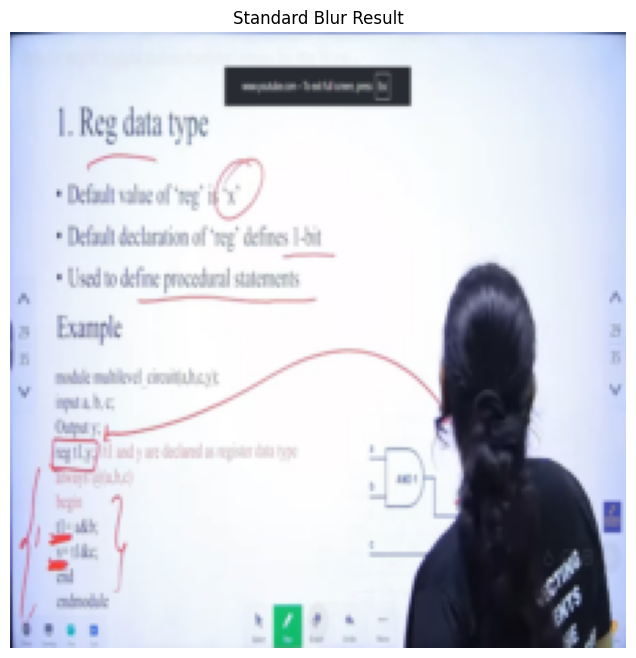

In [65]:
import matplotlib.pyplot as plt
output_tensor = img_tensor.squeeze(0)
output_img = output_tensor.permute(1,2,0)
final_display = output_img.detach().cpu().numpy()

# Step D: Clip the values
# Sometimes math goes slightly over 1.0 or under 0.0; clipping keeps it clean
import numpy as np
final_display = np.clip(final_display, 0, 1)

# Step E: Plot
plt.figure(figsize=(8, 8))
plt.imshow(final_display)
plt.axis('off') # Hide the X and Y numbers
plt.title("Standard Blur Result")
plt.show()